In [4]:
import wandb
wandb.login()
api = wandb.Api()


# totalseg ct
runs = {"patch_icl": {"wandb_name": "j721ty7n"},
        "universeg": {"wandb_name": "x3en0oas"}
}
"""
# totalseg mri
runs = {"patch_icl": {"wandb_name": "etbur6sm"},
        "universeg": {"wandb_name": "mw5v3jpb"}
}
# medsegbench
runs = {"patch_icl": {"wandb_name": "nv7mqd82"},
        "universeg": {"wandb_name": "5s6x367p"}
}
"""
#metrics = api.run(f"/tidiane/patch_icl_eval/{run_names['patch_icl']}").history().transpose()
#wandb_metrics = run.history()
#print(wandb_metrics.columns)
#print(len(wandb_metrics))
#print(run.config)
# keep rows starting with dice_label/ and remove the prefix
#metrics = metrics[metrics.index.str.startswith("dice_label/")]
#metrics.index = metrics.index.str.replace("dice_label/", "")
#keep only first column
#metrics = metrics.iloc[:, 0]

'\n# totalseg mri\nruns = {"patch_icl": {"wandb_name": "etbur6sm"},\n        "universeg": {"wandb_name": "mw5v3jpb"}\n}\n# medsegbench\nruns = {"patch_icl": {"wandb_name": "nv7mqd82"},\n        "universeg": {"wandb_name": "5s6x367p"}\n}\n'

In [5]:
#get train and val labels
# import wandb
#api = wandb.Api()
#metrics = api.run("/tidiane/patch_icl/tidiane/patch_icl/cgzkrjxv").history().transpose()
#metrics[metrics.index.str.startswith("train_dice/")].index.str.replace("train_dice/", "")

In [6]:
# extract the table artifacts
for run_name in runs.keys():
    artifact = api.artifact(f"tidiane/patch_icl_eval/run-{runs[run_name]['wandb_name']}-per_case_dice:v0")
    artifact.download()

    table = artifact.get("per_case_dice.table.json")  # Replace with your table name
    df = table.get_dataframe()
    runs[run_name]["df"] = df

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


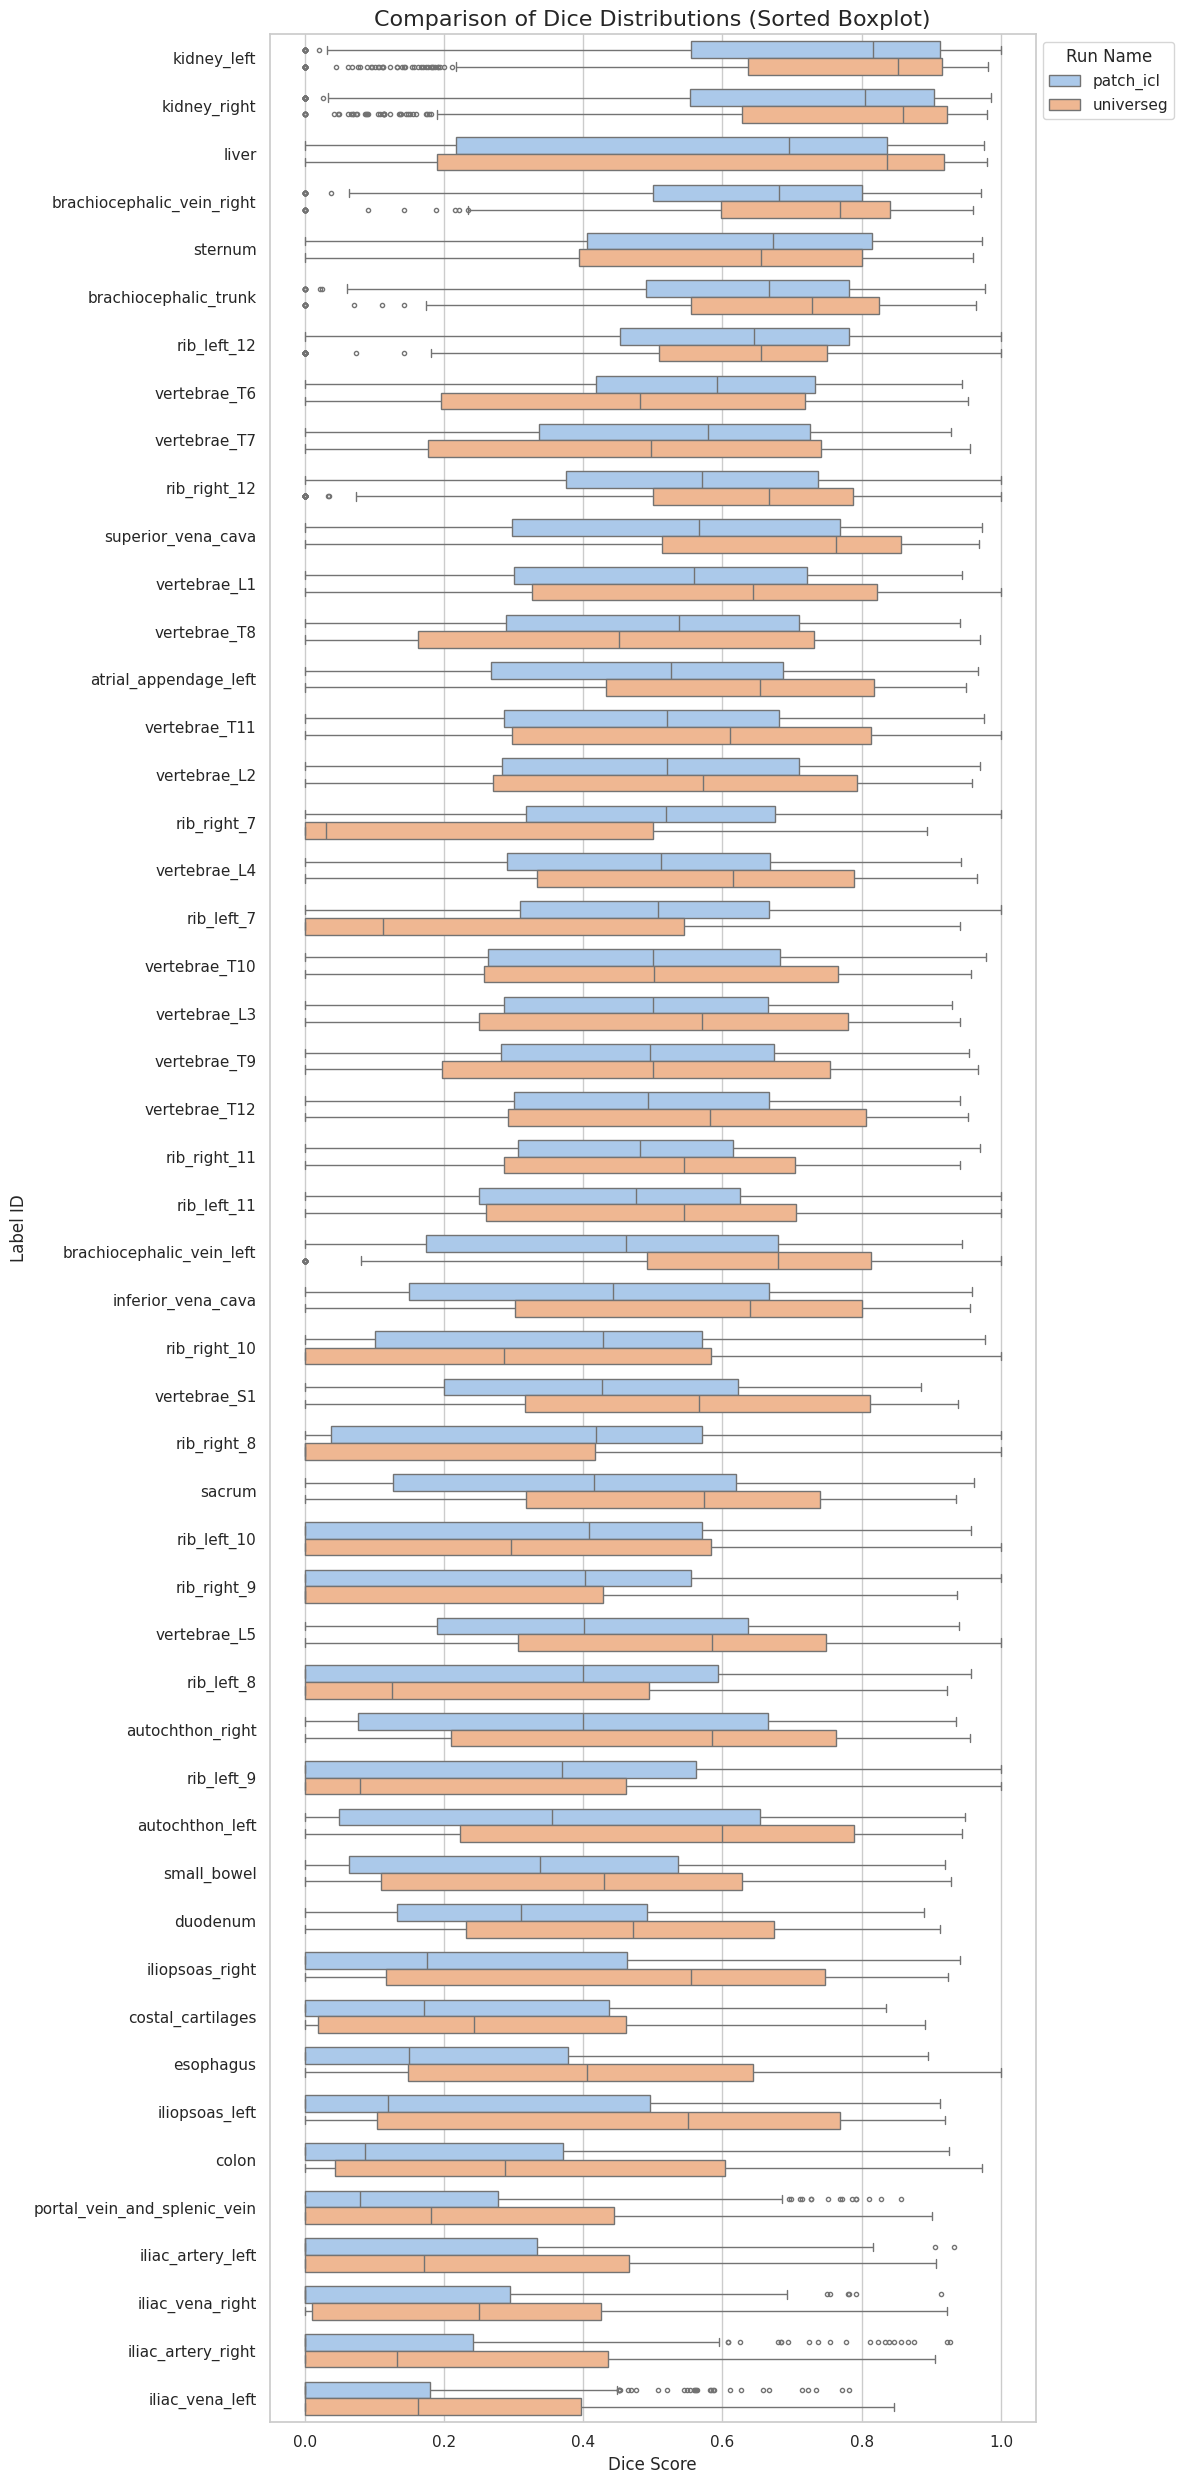

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. MERGE: Combine the two runs into a single DataFrame
combined_data = []

for run_name, run_data in runs.items():
    df_temp = run_data["df"].copy()
    # Add a column to identify the method (Run Name)
    df_temp["Run"] = run_name  
    combined_data.append(df_temp)

df_all = pd.concat(combined_data, ignore_index=True)

# 2. SORT: Calculate median Dice for the first run to sort labels
# This prevents the "random mess" look by creating a waterfall effect.
first_run_name = list(runs.keys())[0]

# Get the sort order (highest median to lowest)
sort_order = df_all[df_all['Run'] == first_run_name] \
             .groupby('label_id')['dice'].median() \
             .sort_values(ascending=False).index

# Apply the sort order to the 'label_id' column
df_all['label_id'] = pd.Categorical(
    df_all['label_id'], 
    categories=sort_order, 
    ordered=True
)

# 3. PLOT: Vertical Boxplot
# Tall height (25) is critical for 50 labels to be readable
plt.figure(figsize=(12, 25)) 
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_all,
    x="dice",           # Metric on X axis
    y="label_id",       # Labels on Y axis
    hue="Run",          # Compare the two runs side-by-side
    orient="h",         # Horizontal orientation
    palette="pastel",   # Softer colors
    width=0.7,          # Adjust box width to fit tightly
    linewidth=1.0,      # Thinner lines for clarity
    fliersize=3         # Smaller outlier dots
)

plt.title('Comparison of Dice Distributions (Sorted Boxplot)', fontsize=16)
plt.xlabel('Dice Score')
plt.ylabel('Label ID')

# Move legend outside if it covers data
plt.legend(title='Run Name', loc='upper left', bbox_to_anchor=(1, 1)) 

plt.tight_layout()
plt.show()

In [8]:
df_all.label_id.unique().tolist()

['iliac_artery_left',
 'iliac_artery_right',
 'colon',
 'small_bowel',
 'sacrum',
 'iliopsoas_left',
 'iliopsoas_right',
 'iliac_vena_left',
 'iliac_vena_right',
 'vertebrae_T6',
 'rib_left_8',
 'brachiocephalic_trunk',
 'autochthon_left',
 'rib_left_7',
 'brachiocephalic_vein_right',
 'superior_vena_cava',
 'rib_right_7',
 'sternum',
 'vertebrae_T7',
 'costal_cartilages',
 'autochthon_right',
 'esophagus',
 'brachiocephalic_vein_left',
 'vertebrae_T8',
 'atrial_appendage_left',
 'rib_right_9',
 'vertebrae_L1',
 'rib_left_9',
 'inferior_vena_cava',
 'kidney_left',
 'vertebrae_T11',
 'liver',
 'rib_right_11',
 'rib_left_11',
 'rib_left_12',
 'vertebrae_T9',
 'rib_right_12',
 'vertebrae_T10',
 'vertebrae_T12',
 'rib_right_10',
 'rib_left_10',
 'rib_right_8',
 'vertebrae_S1',
 'vertebrae_L4',
 'duodenum',
 'vertebrae_L2',
 'portal_vein_and_splenic_vein',
 'vertebrae_L3',
 'kidney_right',
 'vertebrae_L5']

In [13]:
import pickle
import numpy as np
from pathlib import Path

totalseg_dir = Path("/work/dlclarge2/ndirt-SegFM3D/data/totalseg_2d_shared")

with open(totalseg_dir / "stats.pkl", "rb") as f:
    stats_data = pickle.load(f)

# stats_data: {case_id: {shape, spacing, modality, num_slices, labels: {label: {bbox, volume, coverage}}}}
# Compute per-label: occurrences and avg/median volume
label_agg = {}
for case_data in stats_data.values():
    for label, ldata in case_data.get("labels", {}).items():
        if label not in label_agg:
            label_agg[label] = {"occurrences": 0, "volumes": []}
        label_agg[label]["occurrences"] += 1
        label_agg[label]["volumes"].append(ldata["volume"])

rows = [
    {"label_id": lbl, "occurrences": s["occurrences"],
     "avg_volume": np.mean(s["volumes"]), "median_volume": np.median(s["volumes"])}
    for lbl, s in sorted(label_agg.items())
]
df_label_stats = pd.DataFrame(rows).set_index("label_id")
print(df_label_stats.shape)
print(df_label_stats.sort_values("occurrences", ascending=False).head(10))

(117, 3)
                       occurrences     avg_volume  median_volume
label_id                                                        
spinal_cord                   1183   15882.996619        15274.0
autochthon_left               1133   84760.713151        85775.0
autochthon_right              1131   84166.481874        84320.0
aorta                         1102   55548.342105        52714.5
esophagus                     1033    8074.079380         8021.0
lung_upper_lobe_left          1024  222578.120117       231614.5
costal_cartilages             1016   33494.860236        33944.5
lung_lower_lobe_left          1006  198957.605368       187720.5
lung_lower_lobe_right          990  228338.058586       217911.0
inferior_vena_cava             977   17155.522006        16998.0


/tmp/ipykernel_310496/4184586034.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()


patch_icl - Volume Correlation (Spearman): -0.10
universeg - Volume Correlation (Spearman): 0.12
patch_icl - Occurrence Correlation (Spearman): -0.10
universeg - Occurrence Correlation (Spearman): -0.17


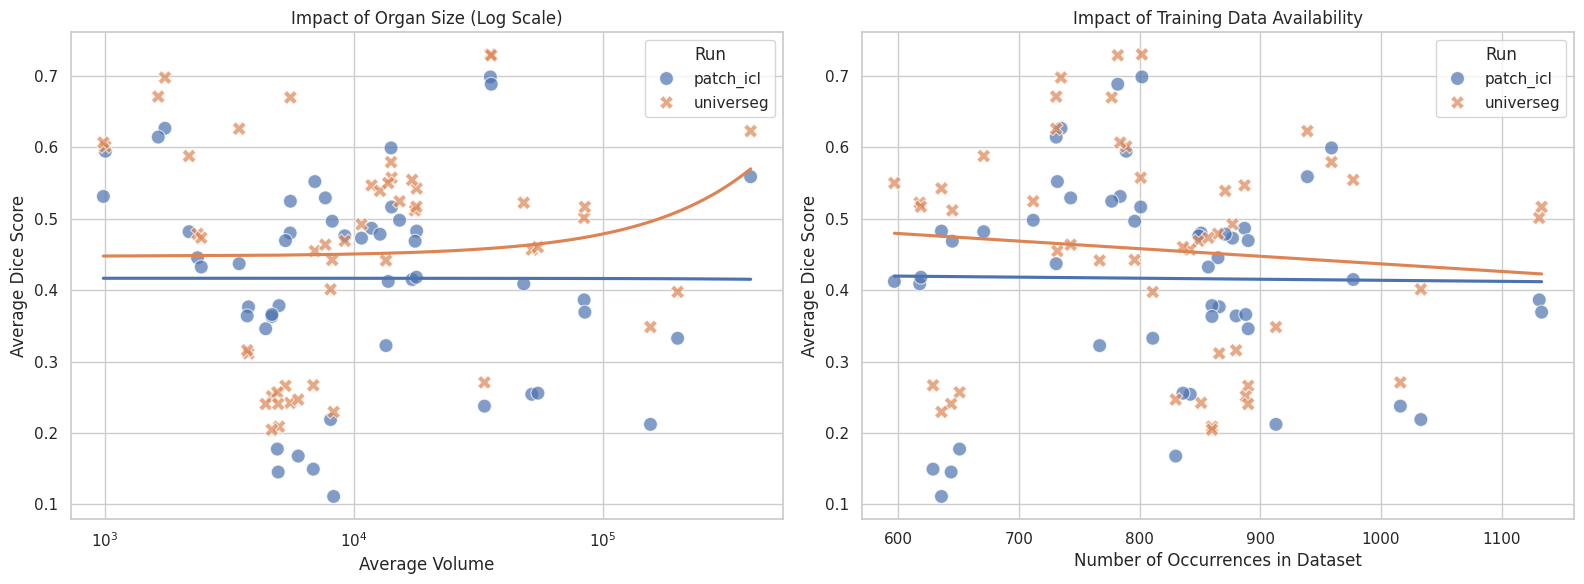

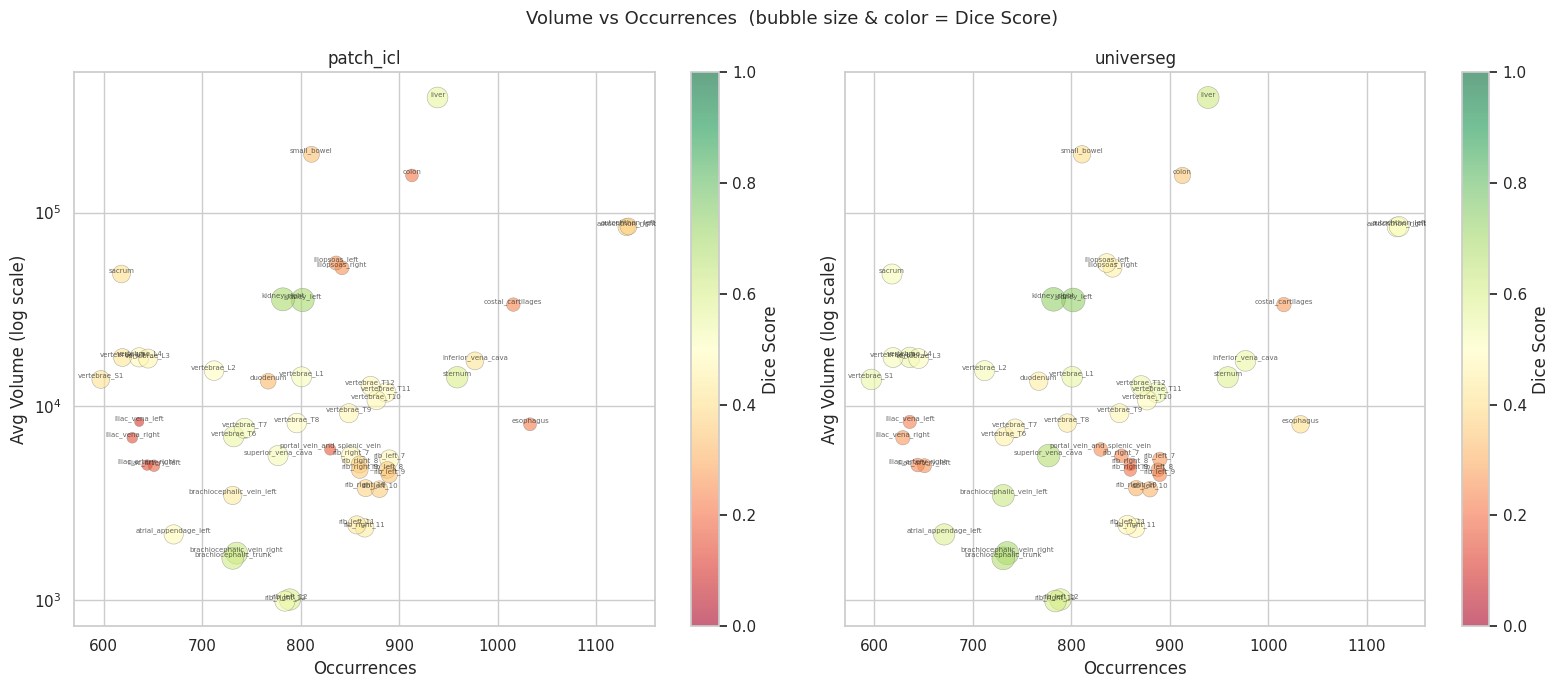

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Prepare data
df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()
df_final = pd.merge(df_dice_avg, df_label_stats.reset_index(), on='label_id')

# 1. Volume vs Dice
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(data=df_final, x="avg_volume", y="dice", hue="Run", style="Run", s=100, alpha=0.7, ax=axes[0])
colors = sns.color_palette()
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(data=subset, x="avg_volume", y="dice", scatter=False, ax=axes[0], color=colors[i], ci=None)
    corr, _ = spearmanr(subset['avg_volume'], subset['dice'])
    print(f"{method} - Volume Correlation (Spearman): {corr:.2f}")
axes[0].set_xscale("log")
axes[0].set_title("Impact of Organ Size (Log Scale)")
axes[0].set_xlabel("Average Volume")
axes[0].set_ylabel("Average Dice Score")

# 2. Occurrences vs Dice
sns.scatterplot(data=df_final, x="occurrences", y="dice", hue="Run", style="Run", s=100, alpha=0.7, ax=axes[1])
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(data=subset, x="occurrences", y="dice", scatter=False, ax=axes[1], color=colors[i], ci=None)
    corr, _ = spearmanr(subset['occurrences'], subset['dice'])
    print(f"{method} - Occurrence Correlation (Spearman): {corr:.2f}")
axes[1].set_title("Impact of Training Data Availability")
axes[1].set_xlabel("Number of Occurrences in Dataset")
axes[1].set_ylabel("Average Dice Score")

plt.tight_layout()
plt.show()

# 3. Multivariate bubble plot: volume vs occurrences, size & color = dice
fig, axes = plt.subplots(1, len(runs), figsize=(8 * len(runs), 7), sharey=True, sharex=True)
if len(runs) == 1:
    axes = [axes]

for ax, (run_name, _) in zip(axes, runs.items()):
    subset = df_final[df_final['Run'] == run_name].copy()
    sizes = (subset['dice'] * 400).clip(lower=10)
    sc = ax.scatter(
        subset['occurrences'], subset['avg_volume'],
        s=sizes, alpha=0.6, c=subset['dice'], cmap='RdYlGn',
        vmin=0, vmax=1, edgecolors='grey', linewidths=0.4
    )
    for _, row in subset.iterrows():
        ax.annotate(row['label_id'], (row['occurrences'], row['avg_volume']),
                    fontsize=5, alpha=0.7, ha='center', va='bottom')
    plt.colorbar(sc, ax=ax, label='Dice Score')
    ax.set_yscale('log')
    ax.set_title(run_name)
    ax.set_xlabel('Occurrences')
    ax.set_ylabel('Avg Volume (log scale)')

plt.suptitle('Volume vs Occurrences  (bubble size & color = Dice Score)', fontsize=13)
plt.tight_layout()
plt.show()